In [3]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
from datetime import datetime, timedelta,timezone
import glob
import os
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import butter, filtfilt, firwin
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d
# from matplotlib.colors import LinearSegmentedColomap
from matplotlib.ticker import AutoMinorLocator

# Set up matplotlib for inline plotting
%matplotlib inline


This is a summary of the rough layout of our project. In this notebook, you will see different code snippets for the project. However, the full working code will be in the project directories. This notebook is not meant to be run, and it will fail. We are not able to upload the data so a lot of the code will simply be a sort of ``pseudo code'' in that sense. I hope it serves as a good introduction. If any questions are to be raised, contact Gustav Jacobsen at s214374@dtu.dk.

It was a requirement to show some shareable data but given the size of the files github will not allow it to be uploaded for this we are sorry.

We load the data and use an extract metadata function, given to us, in order for us to visualize the data and understand it.

We do not show the collection of AIS data here but it is very simply opening the CSV within a ZIP file and then we use chunk size to look through the DataFrame quickly and see if timestamps match the ones we are interested in finding.

Below is some simple code snippets to generate the image. We are not allowed to upload the raw data so the image will have to suffice.

In [2]:
def extract_metadata(file_path):
    """Extract metadata from HDF5 file"""
    with h5py.File(file_path, "r") as hdf5_file:
        start_time = hdf5_file["header/time"][()]
        dt = hdf5_file["header/dt"][()]
        dx = hdf5_file["header/dx"][()]
        channels = hdf5_file["header/channels"][()]
        # Get the actual number of samples in the file
        num_samples = hdf5_file["data"].shape[0]
    return start_time, dt, dx, channels, num_samples
# Get the first 6 files from the directory
directory = "raw_data/GC_data/20250702"
files = sorted(os.listdir(directory))[:6]

# Get all HDF5 files in the directory
file_paths = sorted(glob.glob(os.path.join(directory, '*.hdf5')))
print(len(file_paths))
if not file_paths:
    print(f"No HDF5 files found in {directory}")
else:
    # Extract metadata from the first file
    start_time, dt, dx, channels, num_samples = extract_metadata(file_paths[0])
    fs = 1/dt

    print("Metadata from first file:")
    print(f"Start time (Unix timestamp): {start_time}")
    print(f"Start time (UTC): {datetime.fromtimestamp(start_time, tz=timezone.utc)}")
    print(f"Sampling interval (dt): {dt} seconds")
    print(f"Spatial sampling (dx): {dx} meters")
    print(f"Number of channels: {len(channels)}")
    print(f"Samples per file: {num_samples}")
    print(f"Sampling frequency: {fs} Hz")
    print(f"File duration: {num_samples * dt} seconds")
    print(f"Total files available: {len(file_paths)}")
    print(f"Maximum duration available: {len(file_paths) * num_samples * dt} seconds")

341
Metadata from first file:
Start time (Unix timestamp): 1751458716.152
Start time (UTC): 2025-07-02 12:18:36.152000+00:00
Sampling interval (dt): 0.0016 seconds
Spatial sampling (dx): 1.0213001907746815 meters
Number of channels: 13752
Samples per file: 6250
Sampling frequency: 625.0 Hz
File duration: 10.0 seconds
Total files available: 341
Maximum duration available: 3410.0 seconds


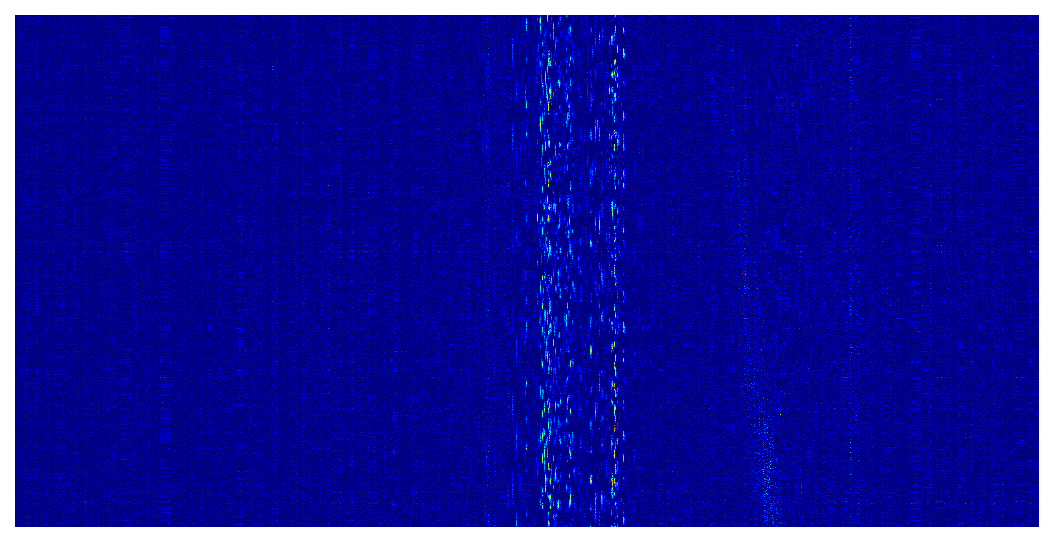

In [4]:
# Use existing variables from notebook
INPUT_DIR = directory
OUTPUT_DIR = "unseen_data"
FS_ASSUMED = fs
DX_ASSUMED_M = dx
DIST_MIN_KM = 4
DIST_MAX_KM = 14
VMAX = 850
IMG_H, IMG_W = 512, 1024
CMAP = "jet"
DPI = 150

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Use first 3 files from file_paths
if len(file_paths) < 3:
    raise ValueError("Need at least 3 files")

p1, p2, p3 = file_paths[0], file_paths[1], file_paths[2]
bases = [os.path.splitext(os.path.basename(p))[0] for p in (p1, p2, p3)]

try:
    slices = []
    for p in (p1, p2, p3):
        with h5py.File(p, 'r') as f:
            dset = f['strainrate'] if 'strainrate' in f else f['data']
            T, C = dset.shape
            distances_km = (np.arange(C) * DX_ASSUMED_M) / 1000.0
            ch_lo = int(math.ceil((DIST_MIN_KM * 1000.0) / DX_ASSUMED_M))
            ch_hi = int(math.floor((DIST_MAX_KM * 1000.0) / DX_ASSUMED_M)) + 1
            ch_lo, ch_hi = max(0, ch_lo), min(ch_hi, C)
            window = dset[:, ch_lo:ch_hi].astype(np.float32)
            slices.append(window)
    
    stitched = np.concatenate(slices, axis=0)
    stitched = np.clip(stitched, 0.0, VMAX) / VMAX
    
    fig = plt.figure(figsize=(IMG_W / DPI, IMG_H / DPI), dpi=DPI)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.imshow(stitched, aspect='auto', cmap=CMAP, vmin=0.0, vmax=1.0, interpolation='nearest')
    
    out_name = f"{bases[0]}_T30s.png"
    out_path = os.path.join(OUTPUT_DIR, out_name)
    plt.show()
except Exception as e:
    print(f"Error: {e}")


This process was repeated for 113 files and we then manually labeled them all by looking at the noise to the right of the static noise.

The code below shows the building of our CNN model and also the loop we create for doing the HP search, and it is saved in a registry using TensorFlow.

In [5]:
# --- Model Definition ---
def build_cnn_model(learning_rate, dropout_rate, num_conv_layers):
    """
    Builds a flexible CNN model based on hyperparameter inputs.
    """
    model = Sequential()
    channels = 1 if getattr(CFG, 'GRAYSCALE_INPUT', False) else getattr(CFG, 'CHANNELS', 3)
    input_shape = (*getattr(CFG, 'IMAGE_SIZE', (256, 256)), channels)
    
    # Initial Conv Block (slightly wider + 5x5 kernel helps diagonal patterns)
    model.add(Conv2D(64, (5, 5), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(dropout_rate))

    # Dynamic Conv Blocks based on num_conv_layers
    for i in range(num_conv_layers - 1):
        # CPU-friendly depth: 64, 128 for large inputs
        filters = 64 * (2 ** i)
        model.add(Conv2D(filters, (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(dropout_rate))

    # Replace Flatten with Global Average Pooling to reduce memory
    model.add(GlobalAveragePooling2D())

    # Dense Layers (smaller head for CPU memory)
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Output layer (Binary Classification: Ship or Noise)
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    # Loss: focal or BCE
    if getattr(CFG, 'USE_FOCAL_LOSS', False):
        alpha = float(getattr(CFG, 'FOCAL_ALPHA', 0.25))
        gamma = float(getattr(CFG, 'FOCAL_GAMMA', 2.0))
        def focal_loss(y_true, y_pred):
            epsilon = tf.keras.backend.epsilon()
            y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
            pt = y_true * y_pred + (1 - y_true) * (1 - y_pred)
            w = alpha * tf.pow(1.0 - pt, gamma)
            return tf.reduce_mean(w * tf.keras.losses.binary_crossentropy(y_true, y_pred))
        loss_fn = focal_loss
    else:
        loss_fn = 'binary_crossentropy'
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss_fn,
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), F1Score()]
    )
    return model

# --- Main Hyperparameter Search and Training ---
def run_hyperparameter_search():
    """
    Executes the grid search, trains models, and writes best-per-run rows to a global registry.
    """
    print("--- Starting Data Load (Tactical Split) ---")
    train_ds, val_ds, test_ds, test_paths, test_labels = load_and_split_data()
    results_dir = Path(getattr(CFG, 'RESULTS_DIR', 'results'))
    results_dir.mkdir(exist_ok=True)

    best_f1 = -1.0
    best_params = {}
    best_threshold = 0.5
    best_epoch = None
    registry_rows = []

    # Setup combinations for grid search
    keys, values = zip(*getattr(CFG, 'HYPERPARAMETER_SPACE', {}).items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"\n--- Starting Hyperparameter Search ({len(combinations)} total runs) ---")

    # Timestamp id for this entire search
    run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
    runs_dir = Path('runs'); runs_dir.mkdir(exist_ok=True)
    
    results = []
    
    best_run_row = None
    for run_num, params in enumerate(combinations):
        print(f"\n[Run {run_num + 1}/{len(combinations)}] Testing parameters: {params}")
        tf.keras.backend.clear_session()
        
        # 1. Build and Compile Model
        model = build_cnn_model(**params)
        
        # 2. Callbacks for Stability and Best Performance Tracking
        callbacks = [
            EarlyStopping(monitor='val_f1_score', patience=getattr(CFG, 'PATIENCE', 5), mode='max', verbose=0),
            ModelCheckpoint(
                filepath=str(Path(getattr(CFG, 'RESULTS_DIR', 'results')) / 'temp_best_model.h5'),
                monitor='val_f1_score',
                mode='max',
                save_best_only=True
            )
        ]
        
        # 3. Train Model
        history = model.fit(
            train_ds,
            epochs=getattr(CFG, 'EPOCHS_PER_RUN', 15),
            validation_data=val_ds,
            callbacks=callbacks,
            verbose=1 # Use 1 for progress bar logging
        )
        
        # 4. Evaluate and Log Results
        
        # Load the best weights from the current run (saved by ModelCheckpoint)
        model.load_weights(str(results_dir / 'temp_best_model.h5')) 
        
        # Evaluate on the validation set at default 0.5 for reference
        metrics = model.evaluate(val_ds, verbose=0)
        val_f1_at_05 = float(metrics[-1])

        # Collect validation labels and probabilities to tune threshold
        y_true = []
        for _, y in val_ds:
            y_true.append(y.numpy().reshape(-1))
        y_true = np.concatenate(y_true, axis=0)
        y_prob = model.predict(val_ds, verbose=0).reshape(-1)

        # Find best threshold maximizing F1
        thresholds = np.linspace(0.05, 0.95, 19)
        best_thr = 0.5
        best_f1_local = -1.0
        best_prec_local = 0.0
        best_rec_local = 0.0
        for t in thresholds:
            preds = (y_prob >= t).astype(int)
            f1 = f1_score(y_true, preds)
            if f1 > best_f1_local:
                best_f1_local = f1
                best_thr = float(t)
                best_prec_local = precision_score(y_true, preds)
                best_rec_local = recall_score(y_true, preds)

        # Additional metrics
        try:
            from sklearn.metrics import roc_auc_score, average_precision_score
            roc_auc = float(roc_auc_score(y_true, y_prob))
            pr_auc = float(average_precision_score(y_true, y_prob))
        except Exception:
            roc_auc = float('nan'); pr_auc = float('nan')
        
        # Best epoch by Keras val_f1_score history
        hist_f1 = history.history.get('val_f1_score', [])
        best_epoch_idx = int(np.argmax(hist_f1)) if len(hist_f1) else None
        best_epoch_num = int(best_epoch_idx + 1) if best_epoch_idx is not None else None

        run_result = {
            'run_id': run_id,
            'combo_id': run_num + 1,
            'learning_rate': params['learning_rate'],
            'dropout_rate': params['dropout_rate'],
            'num_conv_layers': params['num_conv_layers'],
            'best_epoch': best_epoch_num,
            'val_f1_at_0.5': round(val_f1_at_05, 4),
            'val_f1_tuned': round(best_f1_local, 4),
            'val_precision_tuned': round(best_prec_local, 4),
            'val_recall_tuned': round(best_rec_local, 4),
            'best_threshold': best_thr,
            'roc_auc': round(roc_auc, 4) if roc_auc == roc_auc else None,
            'pr_auc': round(pr_auc, 4) if pr_auc == pr_auc else None,
        }
        results.append(run_result)
        print(f"Validation F1 (tuned) for Run {run_num + 1}: {best_f1_local:.4f} @ threshold {best_thr:.2f}")

        # 5. Track the overall best model
        if best_f1_local > best_f1:
            best_f1 = best_f1_local
            best_params = params
            best_threshold = best_thr
            best_epoch = best_epoch_num
            print(f"*** New CHAMPION (F1: {best_f1:.4f} @ {best_threshold:.2f}) with params: {best_params} ***")
            # Save champion model to results directory
            model.save(str(results_dir / 'champion_model.h5'))
            # Prepare champion row
            best_run_row = {
                'run_id': run_id,
                'combo_id': run_num + 1,
                'learning_rate': params['learning_rate'],
                'dropout_rate': params['dropout_rate'],
                'num_conv_layers': params['num_conv_layers'],
                'best_epoch': best_epoch_num,
                'val_f1_tuned': round(best_f1_local, 4),
                'best_threshold': best_threshold,
                'val_precision_tuned': round(best_prec_local, 4),
                'val_recall_tuned': round(best_rec_local, 4),
                'roc_auc': round(roc_auc, 4) if roc_auc == roc_auc else None,
                'pr_auc': round(pr_auc, 4) if pr_auc == pr_auc else None
            }
            
    # Print and Save Search Summary
    # Print summary table (optional) but only persist champion row
    results_df = pd.DataFrame(results)
    print("\n--- Hyperparameter Search Summary (All Runs) ---")
    print(results_df.to_string(index=False))

    if best_run_row is not None:
        try:
            registry = Path('runs') / 'registry.csv'
            pd.DataFrame([best_run_row]).to_csv(registry, mode='a', header=not registry.exists(), index=False)
            print(f"Champion row appended to {registry}")
        except Exception as e:
            print(f"Warning: failed to update registry with champion row: {e}")
    else:
        print("Warning: No champion row recorded (no runs?)")

    return best_params, best_threshold, test_ds, test_paths, test_labels


After having built and trained the model we evaluated it on the test set using the following code snippet.

In [ ]:
# --- Final Anomaly Prediction ---
def evaluate_on_test(best_params, threshold: float, test_ds, test_paths, test_labels):
    """
    Evaluate the champion model on the held-out test set.
    """
    print("\n--- Evaluating Champion on Test Holdout ---")

    results_dir = Path(getattr(CFG, 'RESULTS_DIR', 'results'))
    champion_path = results_dir / 'champion_model.h5'
    if champion_path.exists():
        best_model = tf.keras.models.load_model(str(champion_path), compile=False)
        best_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                          loss='binary_crossentropy',
                          metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), F1Score()])
    else:
        best_model = build_cnn_model(**best_params)
        best_model.load_weights(getattr(CFG, 'MODEL_SAVE_PATH', 'best_ship_detector.h5'))

    probabilities = best_model.predict(test_ds, verbose=0).reshape(-1)
    preds = (probabilities >= threshold).astype(int)
    y_true = np.array(test_labels).astype(int)

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    report = pd.DataFrame({
        'filename': [os.path.basename(p) for p in test_paths],
        'true_label': y_true,
        'ship_probability': probabilities,
        'prediction': preds
    }).sort_values(by='ship_probability', ascending=False)
    # CRITICAL TEST: Day A Ship Classification (prefix '00' and true_label==1)
    critical_idx = None
    for i, (fname, tl) in enumerate(zip(report['filename'].tolist(), y_true.tolist())):
        if fname.startswith('00') and tl == 1:
            critical_idx = i
            break
    if critical_idx is not None:
        crit_fname = report['filename'].iloc[critical_idx]
        crit_prob = report['ship_probability'].iloc[critical_idx]
        crit_pred = 'SHIP' if report['prediction'].iloc[critical_idx] == 1 else 'NOISE'
        print(f"CRITICAL TEST: Day A Ship Classification → file={crit_fname}, prob={crit_prob:.4f}, pred={crit_pred}")
    else:
        print("CRITICAL TEST: Day A Ship image not found in test set.")

    out_csv = results_dir / 'champion_test_predictions.csv'
    report.to_csv(out_csv, index=False)

    print(f"Test metrics — Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    print(f"Saved test predictions: {out_csv}")


Now here we cross reference with AIS and see if timestamps match. Further detail on those scripts are in the AIS folder, but since we cannot upload data, I will not post the code here.

However we also have performed FFT and that can be seen below.

In [ ]:
def find_start_file(file_paths, start_time_str):
    """Find the first file at or after the specified start time (HHMMSS format)"""
    # Convert input time string to datetime.time object
    try:
        input_time = datetime.strptime(start_time_str, "%H%M%S").time()
    except ValueError:
        raise ValueError("Invalid time format. Please use HHMMSS format (e.g., 102030)")

    # Find all files that match the time pattern
    time_files = []
    for file_path in file_paths:
        filename = os.path.basename(file_path)
        if filename.endswith('.hdf5'):
            time_str = filename.split('.')[0]
            try:
                file_time = datetime.strptime(time_str, "%H%M%S").time()
                time_files.append((file_time, file_path))
            except ValueError:
                continue

    if not time_files:
        raise ValueError("No valid time-based HDF5 files found in the directory")

    # Sort files by time
    time_files.sort()

    # Find the first file at or after the requested time
    for file_time, file_path in time_files:
        if file_time >= input_time:
            return file_path, time_files.index((file_time, file_path))

    # If we get here, all files are before requested time - return last file
    return time_files[-1][1], len(time_files) - 1

def compute_spectrogram(signal, fs, Nfft=2048, overlap=0.9, file_time=None):
    """Compute spectrogram using matplotlib's specgram function"""
    Nover = int(np.floor(Nfft * overlap))
    pspect, fspect, tspect = plt.mlab.specgram(
        signal,
        NFFT=Nfft,
        Fs=fs,
        window=np.hanning(Nfft),
        noverlap=Nover,
        mode="psd",
    )
    psd = 10 * np.log10(pspect)
    if file_time:
        tspect_utc = [datetime.fromtimestamp(file_time) + timedelta(seconds=t) for t in tspect]
    else:
        tspect_utc = tspect
    return np.array(tspect_utc), fspect, psd


DIRECTORY = "../raw_data/GC_data/20250702"

file_paths = sorted(glob.glob(os.path.join(DIRECTORY, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {DIRECTORY}")

# Pull timestamps and channels from Cell 1 results
try:
    TIMESTAMPS = [r['timestamp'] for r in results]
    CHANNEL_IDS_FROM_CELL1 = [int(r['best_channel_index']) for r in results]  # Treat as channel IDs from metadata
except Exception as e:
    raise RuntimeError("Cell 1 must be run first to populate 'results' with best channels.")

# Load metadata to get the channels array (actual channel IDs)
_, dt_meta, dx_meta, channels_meta, _ = extract_metadata(file_paths[0])
max_channel_index = len(channels_meta) - 1

def channel_id_to_index(channel_ids_array, requested_id):
    """Map a channel ID (value in channels array) to its zero-based column index. If not found, choose nearest by distance."""
    matches = np.where(channel_ids_array == requested_id)[0]
    if matches.size > 0:
        return int(matches[0]), False
    # Nearest by distance: convert IDs to km distance using dx_meta, find closest distance to requested_id*dx
    distances_m = channel_ids_array * dx_meta
    target_m = requested_id * dx_meta
    idx = int(np.argmin(np.abs(distances_m - target_m)))
    return idx, True

# Ensure alignment
if len(TIMESTAMPS) != len(CHANNEL_IDS_FROM_CELL1):
    raise ValueError("Mismatch: number of timestamps and discovered channels differ.")

SPECTROGRAM_CHUNK_SIZE = 3   # 3 files × 10s = ~30 seconds

# Spectrogram plotting params
fmax = 125
vmin_db = 10
vmax_db = 30
time_tolerance = 0.05
Nfft = 4096
OVERLAP = 0.9

def find_start_index(file_paths, ts_str):
    try:
        _, start_idx = find_start_file(file_paths, ts_str)
        return start_idx
    except Exception as e:
        raise RuntimeError(f"Could not locate start time {ts_str}: {e}")

def load_channel_block(file_paths, ts_str, requested_channel_id):
    start_idx = find_start_index(file_paths, ts_str)
    sel_paths = file_paths[start_idx : min(start_idx + SPECTROGRAM_CHUNK_SIZE, len(file_paths))]
    if len(sel_paths) < SPECTROGRAM_CHUNK_SIZE:
        print(f"Warning: Only {len(sel_paths)} files found starting at {ts_str}")
    all_channel_data = []
    file_start_time = None
    dt_ref = None
    channels_ref = None
    file_duration = None
    processed_files_count = 0
    channel_distance_km = None
    dx_last = None
    ch_index_used = None
    # Determine zero-based index for the requested channel ID using the first file's metadata
    try:
        s_time0, s_dt0, s_dx0, s_channels0, s_num0 = extract_metadata(sel_paths[0])
        idx0, was_mapped = channel_id_to_index(s_channels0, requested_channel_id)
        ch_index_used = idx0
        if was_mapped:
            print(f"[WARN] Channel ID {requested_channel_id} not found; using nearest at index {idx0} (ID {int(s_channels0[idx0])})")
    except Exception as e:
        # Fallback: assume ID equals index
        ch_index_used = requested_channel_id
    for i, file_path in enumerate(sel_paths):
        try:
            current_start_time, current_dt, dx, current_channels, num_samples = extract_metadata(file_path)
        except Exception as e:
            print(f"Skipping metadata for {file_path}: {e}")
            continue
        dx_last = dx
        current_file_duration = num_samples * current_dt
        if file_start_time is None:
            file_start_time = current_start_time
            dt_ref = current_dt
            channels_ref = current_channels
            file_duration = current_file_duration
        if not np.isclose(current_dt, dt_ref, atol=1e-12):
            print(f"Skipping {os.path.basename(file_path)}: dt mismatch ({current_dt} != {dt_ref})")
            continue
        if ch_index_used >= len(current_channels):
            print(f"Selected channel index {ch_index_used} out of range for {os.path.basename(file_path)} (max {len(current_channels)-1})")
            break
        expected_start = file_start_time + processed_files_count * file_duration
        if not np.isclose(current_start_time, expected_start, atol=time_tolerance):
            print(f"Skipping {os.path.basename(file_path)}: start {current_start_time} not contiguous (expected {expected_start})")
            break
        try:
            with h5py.File(file_path, "r") as f:
                channel_data = f["data"][:, ch_index_used]
                all_channel_data.append(channel_data)
                processed_files_count += 1
        except Exception as e:
            print(f"Skipping file {os.path.basename(file_path)} due to read error: {e}")
    if not all_channel_data:
        return None, None, None, None, None, None
    combined = np.concatenate(all_channel_data)
    fs = 1.0 / dt_ref
    # Compute km distance from channel ID (preferred) if available, else from index
    try:
        ch_id_used = int(channels_ref[ch_index_used])
    except Exception:
        ch_id_used = requested_channel_id
    distance_km = (ch_id_used * dx_last) / 1000.0 if dx_last is not None else None
    return combined, fs, dt_ref, file_start_time, distance_km, ch_id_used, ch_index_used

# Build grid: one column per timestamp-channel pair
n = len(TIMESTAMPS)
rows = int(np.ceil(n / 2))
cols = 2 if n > 1 else 1
fig, axes = plt.subplots(rows, cols, figsize=(12, 6), sharex=False, sharey=True, constrained_layout=True)
axes = np.array(axes).reshape(rows, cols)

idx = 0
last_im = None
for r in range(rows):
    for c in range(cols):
        if idx >= n:
            axes[r, c].set_axis_off()
            continue
        ts = TIMESTAMPS[idx]
        ch_id = CHANNEL_IDS_FROM_CELL1[idx]
        ax = axes[r, c]
        data, fs, dt_ref, file_start_time, channel_distance_km, ch_id_used, ch_index_used = load_channel_block(file_paths, ts, ch_id)
        if data is None:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
            ax.set_axis_off()
            idx += 1
            continue
        # Compute spectrogram
        tspect, fspect, psd = compute_spectrogram(
            data,
            fs,
            Nfft=Nfft,
            overlap=OVERLAP,
            file_time=file_start_time
)
        # Plot
        tspect_num = mdates.date2num(tspect)
        T, F = np.meshgrid(tspect_num, fspect)
        last_im = ax.pcolormesh(T, F, psd, cmap="jet", vmin=vmin_db, vmax=vmax_db, shading="auto")
        ax.set_ylim(3, fmax)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        # X ticks at 10-second increments
        ax.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
        # Add km stamp at top-left
        if channel_distance_km is not None:
            ax.text(0.01, 0.99, f"{channel_distance_km:.3f} km", transform=ax.transAxes, ha='left', va='top', fontsize=18, color='white', bbox=dict(facecolor='black', alpha=0.4, edgecolor='none', pad=2))
        # Remove titles as requested
        # ax.set_title(f"{ts} | channel ID {ch_id_used} @ {channel_distance_km:.3f} km (index {ch_index_used})", fontsize=10)
        if r == rows - 1:
            ax.set_xlabel("Time (UTC)", fontsize=18)
        if c == 0:
            ax.set_ylabel("Freq [Hz]", fontsize=18)
        # Increase tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=18)
        idx += 1

# Colorbar (ensure it does not overlap with subplots)
if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("PSD [dB]", fontsize=18)
    # Match tick label sizes to axes
    cbar.ax.tick_params(labelsize=18, which='major', length=6, width=1.2)
    # Minor ticks between majors
    cbar.ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.show()

print("Spectrogram grid built from Cell 1 results (channel IDs):")
for ts, ch in zip(TIMESTAMPS, CHANNEL_IDS_FROM_CELL1):
    print(f"  {ts}: requested channel ID {ch}")
print("Note: If a channel ID wasn't present, the nearest by distance was used; titles were removed by request.")
print(f"Each panel: 3 files (~30s), Nfft={Nfft}, overlap={OVERLAP}")

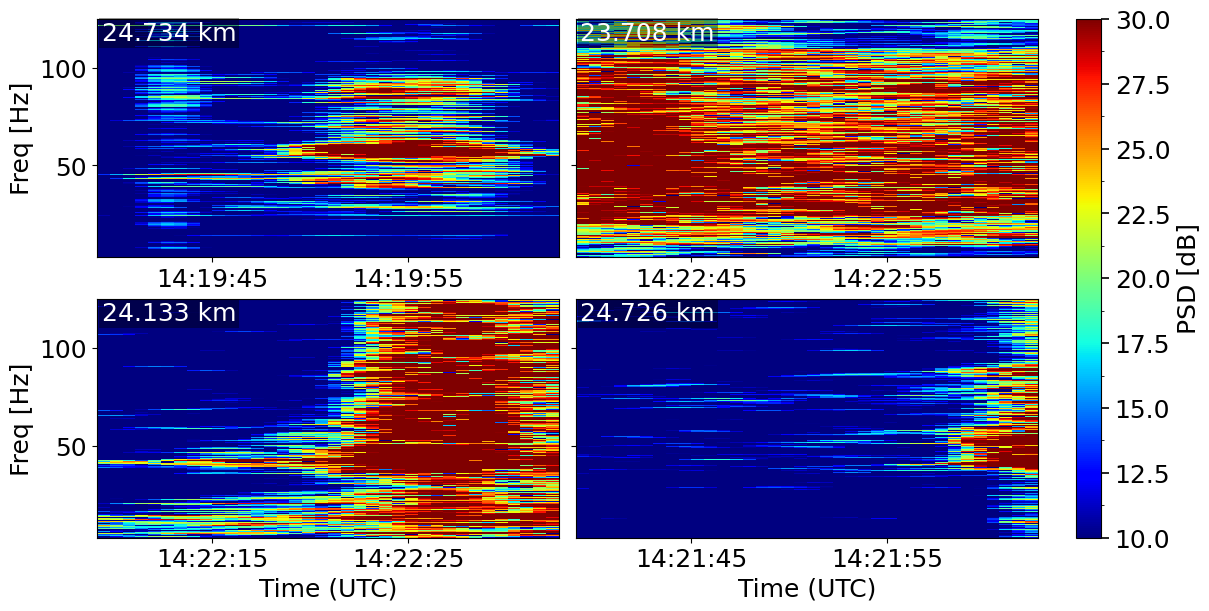